In [15]:
import numpy as np
import seaborn as sns
import pandas as pd
import scipy.stats as st
#import theano.tensor as tt
import matplotlib.pyplot as plt
from ann_functions import import_data
from keras.models import load_model
from keras.initializers import glorot_uniform
import keras.backend as K
from keras.utils import custom_object_scope

np.random.seed(42)


In [16]:
def NN_MF(q,K1,K2,K3):
    out1=K1.predict(q)
 #   print(out1.shape)
 #   print(q.shape)
    in2 = np.hstack((q, out1))
    out2=K2.predict(in2)
    in3 = np.hstack((in2, out2))
    approx_model_output=K3.predict(in3)
    return approx_model_output
    

def Metropolis_Hastings(q0, N, sigma, U_test, K1,K2,K3): # implementation of the Random Walk Metropolis-Hastings algorithm
    # q0= initial value 
    # N = length Markov chain
    # sigma = std deviation
    # U_test = test set
    # K1 = first NN
    # K2 = second NN
    # K3 = third NN

    dimension= q0.shape[0]
    q = np.zeros([N+1, dimension])
    q[0, :] = q0.T
    #print(q[0,:])
    accepted = 0
    rejected = 0
    U_NN_old=NN_MF(q0,K1,K2,K3)
    #print(U_NN_old)
    for i in range(N):
        #q_star = np.random.multivariate_normal(mean=q[i, :], cov=sigma*np.eye(dimension))
        q_star=np.random.uniform(0.5, 1.5, size=(1, dimension))
       # print(q_star)
        U_NN=NN_MF(q_star.reshape(dimension,1),K1,K2,K3)
       # print(U_NN)
        #value_old=np.exp(((U_NN-U_test)@(U_NN-U_test)/(2*sigma)))
        a = np.exp(((U_NN.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))@(U_NN.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))/(2*sigma)))/np.maximum(np.exp(((U_NN_old.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))@(U_NN_old.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))/(2*sigma))), np.finfo(np.float64).eps)
       # print("--")
       # print(a)
        u = np.random.uniform()
        if (u<a):
            q[i+1, :] = q_star
            accepted = accepted+1
            U_NN_old=U_NN
        else:
            q[i+1, :] = q[i, :]
            rejected = rejected+1
    ratio = accepted/(accepted+rejected)
    return q, ratio, U_NN

def autocovariance(X): # Autocovariance of a Markov chain X, X tail of q after burn-in lag B
    mu = np.mean(X, axis=0)
    N = len(X[:, 0])
    cov = np.zeros([N-1, X.shape[1]])
    
    for k in range(N-1):
        for i in range(N-k-1):
            cov[k, :] += ((X[i+k, :])-mu)*(X[i, :]-mu)
        cov[k, :] = (1/(N-k-1))*cov[k, :]
        
    return cov

def autocorrelation(autocov): # Autocorrelation of a Markov chain, calculated from its autocovariance
    corr = np.zeros(np.shape(autocov))
    for i in range(int(len(autocov[0, :, 0]))):
        corr[:, i, 0] = np.divide(autocov[:, i, 0], np.maximum(np.abs(autocov[:, 0, 0]), np.finfo(np.float64).eps))
        corr[:, i, 1] = np.divide(autocov[:, i, 1], np.maximum(np.abs(autocov[:, 0, 1]), np.finfo(np.float64).eps))
    
    return corr

def get_M(autocov): # Last element of the chain used to calculate sigma^2_mcmc
    M1 = None
    for k in range(int(len(autocov[:, 0])/2)):
        if ((autocov[2*k, 0] + autocov[2*k+1, 0])<=0):
            M1 = 2*k
            break
    if M1 is None:
        M1 = int(len(autocov[:, 0])-2)
    M2 = None
    for j in range(int(len(autocov[:, 1])/2)):
        if ((autocov[2*j, 1] + autocov[2*j+1, 1])<=0) :
            M2 = 2*j
            break
    if M2 is None:
        M2 = int(len(autocov[:, 1])-2)
    
    return M1, M2

def get_sigma(autocov): # Time-average variance constant of a Markov chain, calculated from its autocovariance
    # Calculate the
    [M1, M2] = get_M(autocov)
    id1 = range(1, M1)
    S1 = autocov[0, 0] + 2*np.sum(autocov[id1, 0])
    id2 = range(1, M2)
    S2 = autocov[0, 1] + 2*np.sum(autocov[id2, 1])

    return [S1, S2]


def effective_sample_size(autocov): # effective sample size of a Markov chain, calculated from its autocovariance
    [n, N] = np.shape(autocov[:, :, 0])
    ess = np.zeros([n, 2])
    for i in range(n):
        sigma = get_sigma(autocov[i, :, :])
        ess[i, 0] = N*np.divide(autocov[i, 0, 0], np.maximum(sigma[0],  np.finfo(np.float64).eps))
        ess[i, 1] = N*np.divide(autocov[i, 0, 1], np.maximum(sigma[1],  np.finfo(np.float64).eps))

    return ess

In [17]:
# cell 1                                                        
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, -1, 44,44]
# ADD NOISE
noise_stddev = np.mean(U_HF_test) * 0.01       # value?
noise = np.random.normal(0, noise_stddev, len(U_HF_test))
U_HF_test_selection = U_HF_test + noise


permutation = np.random.permutation(len(U_HF_test_selection))
n_HF = 15
U_HF_test_selection = U_HF_test_selection[permutation][0:n_HF]

# Definisci la tua funzione di attivazione personalizzata (in codice finale, dove tutto andrà da inizio a fine, non credo questa parte sarà più necessaria...)
def custom_activation(x):
    # Implementa la tua logica personalizzata qui
    return x + K.square(K.sin(x))

# Aggiungi la tua funzione di attivazione personalizzata al dizionario custom_objects
custom_objects = {'custom_activation': custom_activation, 'glorot_uniform': glorot_uniform()}

# Carica il modello utilizzando custom_objects
with custom_object_scope(custom_objects):
    keras_model1 = load_model("modelLF.h5")
    keras_model2 = load_model("modelLin.h5")
    keras_model3 = load_model("finalModel.h5")



MemoryError: Unable to allocate 2.98 GiB for an array with shape (50, 801, 100, 100) and data type float64

1/1 [==============================] - 0s 22ms/step
Iteration:  3 / 30
1/1 [==============================] - 0s 25ms/step
Iteration:  6 / 30
1/1 [==============================] - 0s 29ms/step
Iteration:  9 / 30
1/1 [==============================] - 0s 29ms/step
Iteration:  12 / 30
1/1 [==============================] - 0s 44ms/step
Iteration:  15 / 30
1/1 [==============================] - 0s 30ms/step
Iteration:  18 / 30
1/1 [==============================] - 0s 29ms/step
Iteration:  21 / 30
1/1 [==============================] - 0s 26ms/step
Iteration:  24 / 30
1/1 [==============================] - 0s 28ms/step
Iteration:  27 / 30
1/1 [==============================] - 0s 28ms/step
Iteration:  30 / 30
Calculating covariance...
Calculating correlation...
Calculating ESS...


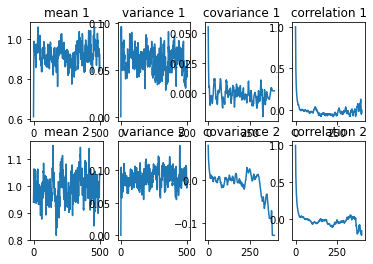

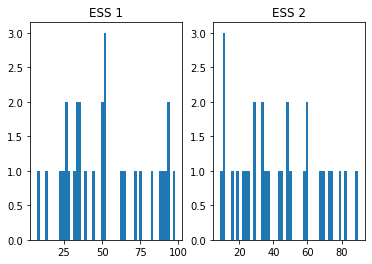

In [ ]:
mu_0=np.random.uniform(0.5,1.5,size=(U_HF_test_selection.shape[0],1))
sigma=1
N=100
n=10

final_q = np.zeros([n, U_HF_test_selection.shape[0]])
final_q_ham = np.zeros([n, U_HF_test_selection.shape[0]])
ratio = np.zeros(n)
big_q = np.zeros([n,N+1, U_HF_test_selection.shape[0]])
big_q_ham = np.zeros([n,N+1, U_HF_test_selection.shape[0]])

for i in range(n):
        q, ratio,U = Metropolis_Hastings(mu_0, N, sigma,U_HF_test_selection,keras_model1,keras_model2,keras_model3)
        final_q[i, :] = q[-1, :]
        big_q[i, :, :] = q
        if (i+1)%(int(np.floor(n/10))) == 0:
            print("Iteration: ", i+1, "/", n)

exp_q = np.mean(big_q, axis=0)
var_q = np.var(big_q, axis=0)


## Calculate autocorrelation of both chains q(:, 0) and q(:, 1)
B = 20
idx = B+np.asarray(range(N-B))

tail_qx = big_q[:, idx, 0]
tail_qy = big_q[:, idx, 1]
tail_q = big_q[:, idx, :]
tail_qx_ham = big_q_ham[:, idx, 0]
tail_qy_ham = big_q_ham[:, idx, 1]

print("Calculating covariance...")
cov = np.zeros([n, len(idx)-1, tail_q.shape[2]])
for i in range(n):
    cov[i, :, :] = autocovariance(tail_q[i, :, :])
print("Calculating correlation...")
corr = np.mean(autocorrelation(cov), axis=0)


## Calculate effective sample size
print("Calculating ESS...")
ESS = effective_sample_size(cov)
ESS = np.sort(ESS, axis=0)
id_min_ESS = int(np.floor(n/40))
id_ESS = id_min_ESS+np.asarray(range(n-2*id_min_ESS))
ESS_reduced = ESS[id_ESS, :]


avx = np.reshape(tail_qx, -1)
avy = np.reshape(tail_qy, -1)
avx_ham = np.reshape(tail_qx_ham, -1)
avy_ham = np.reshape(tail_qy_ham, -1)

# ancora regolato su caso bidimensionale
fig, axs2 = plt.subplots(2, 4)
axs2[0, 0].plot(exp_q[:, 0])
axs2[0, 0].set_title('mean 1')
axs2[1, 0].plot(exp_q[:, 1])
axs2[1, 0].set_title('mean 2')

axs2[0, 1].plot(var_q[:, 0])
axs2[0, 1].set_title('variance 1')

axs2[1, 1].plot(var_q[:, 1])
axs2[1, 1].set_title('variance 2')
axs2[0, 2].plot(cov[-1, :, 0])
axs2[0, 2].set_title('covariance 1')
axs2[1, 2].plot(cov[-1, :, 1])
axs2[1, 2].set_title('covariance 2')

axs2[0, 3].plot(corr[:, 0])
axs2[0, 3].set_title('correlation 1')

axs2[1, 3].plot(corr[:, 1])
axs2[1, 3].set_title('correlation 2')



fig, ax3 = plt.subplots(1, 2)
ax3[0].hist(ESS_reduced[:, 0], 25, density=False)
ax3[0].set_title('ESS 1')

ax3[1].hist(ESS_reduced[:, 1], 25, density=False)
ax3[1].set_title('ESS 2')




plt.show()                        


            

Calculating covariance...
Calculating correlation...
Calculating ESS...


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20792\2024825911.py:40: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()  # Crea una nuova figura per ogni iterazione del ciclo


<Figure size 432x288 with 0 Axes>

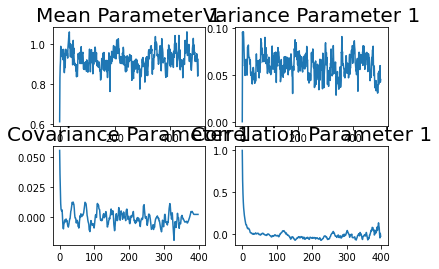

<Figure size 432x288 with 0 Axes>

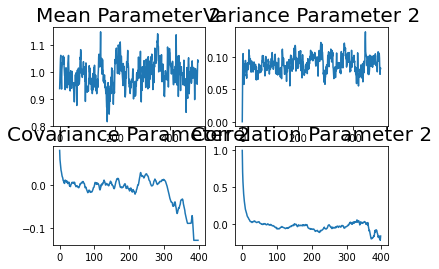

<Figure size 432x288 with 0 Axes>

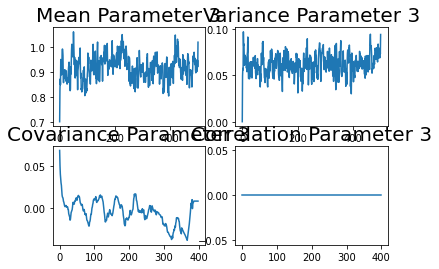

<Figure size 432x288 with 0 Axes>

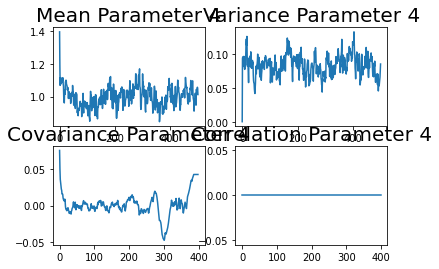

<Figure size 432x288 with 0 Axes>

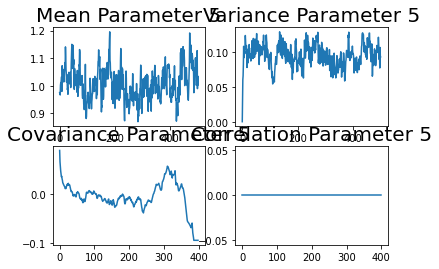

<Figure size 432x288 with 0 Axes>

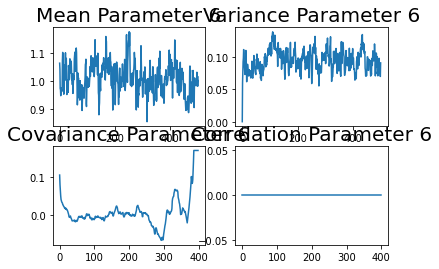

<Figure size 432x288 with 0 Axes>

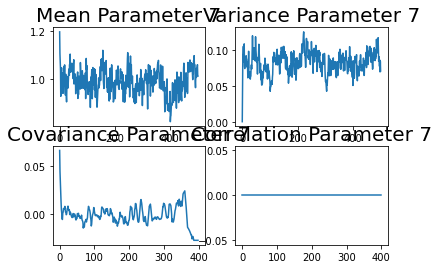

<Figure size 432x288 with 0 Axes>

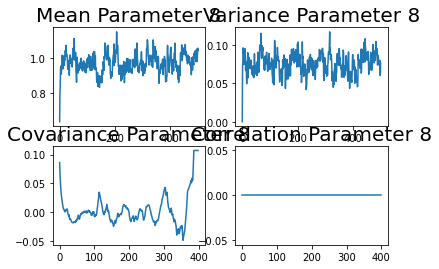

<Figure size 432x288 with 0 Axes>

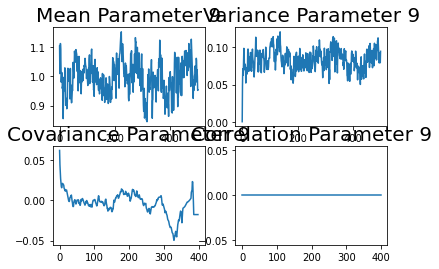

<Figure size 432x288 with 0 Axes>

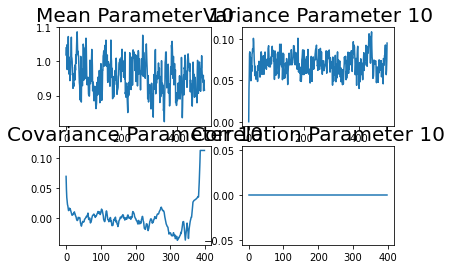

<Figure size 432x288 with 0 Axes>

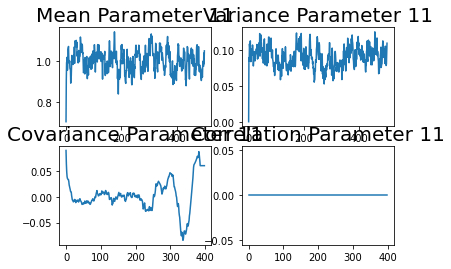

<Figure size 432x288 with 0 Axes>

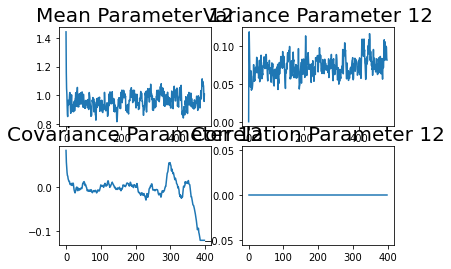

<Figure size 432x288 with 0 Axes>

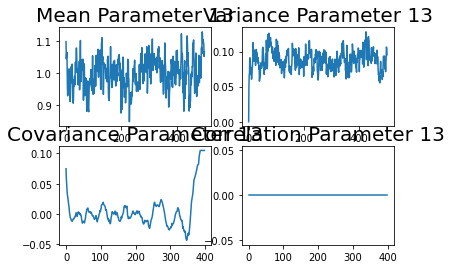

<Figure size 432x288 with 0 Axes>

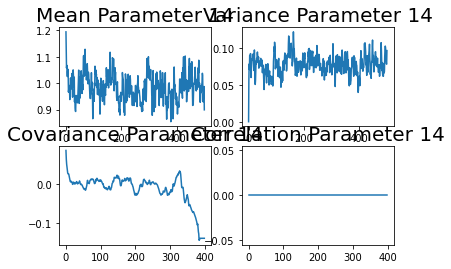

<Figure size 432x288 with 0 Axes>

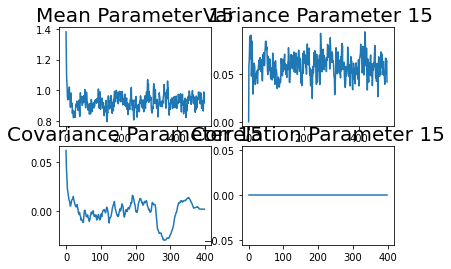

In [ ]:
exp_q = np.mean(big_q, axis=0)
var_q = np.var(big_q, axis=0)


## Calculate autocorrelation of both chains q(:, 0) and q(:, 1)
B = 100
idx = B+np.asarray(range(N-B))

tail_qx = big_q[:, idx, 0]
tail_qy = big_q[:, idx, 1]
tail_q = big_q[:, idx, :]
tail_qx_ham = big_q_ham[:, idx, 0]
tail_qy_ham = big_q_ham[:, idx, 1]

print("Calculating covariance...")
cov = np.zeros([n, len(idx)-1, tail_q.shape[2]])
for i in range(n):
    cov[i, :, :] = autocovariance(tail_q[i, :, :])
print("Calculating correlation...")
corr = np.mean(autocorrelation(cov), axis=0)


## Calculate effective sample size
print("Calculating ESS...")
ESS = effective_sample_size(cov)
ESS = np.sort(ESS, axis=0)
id_min_ESS = int(np.floor(n/40))
id_ESS = id_min_ESS+np.asarray(range(n-2*id_min_ESS))
ESS_reduced = ESS[id_ESS, :]


avx = np.reshape(tail_qx, -1)
avy = np.reshape(tail_qy, -1)
avx_ham = np.reshape(tail_qx_ham, -1)
avy_ham = np.reshape(tail_qy_ham, -1)

# ancora regolato su caso bidimensionale

for i in range(U_HF_test_selection.shape[0]):
    plt.figure()  # Crea una nuova figura per ogni iterazione del ciclo
    fig, axs2 = plt.subplots(2, 2)
    axs2[0, 0].plot(exp_q[:, i])
    axs2[0, 0].set_title(f"Mean Parameter {i+1}", fontsize=20)
    
    axs2[0, 1].plot(var_q[:, i])
    axs2[0, 1].set_title(f"Variance Parameter {i+1}", fontsize=20)
    
    axs2[1, 0].plot(cov[-1, :, i])
    axs2[1, 0].set_title(f"Covariance Parameter {i+1}", fontsize=20)
    
    axs2[1, 1].plot(corr[:, i])
    axs2[1, 1].set_title(f"Correlation Parameter {i+1}", fontsize=20)
    
    # per effective sample size rifare funzione originaria che tiene ancora conto solo di due parametri
    #plt.figure()
    #plt.hist(ESS_reduced[:, i], 25, density=False, label=f"ESS Parameter {i+1}")
    
    






plt.show() 

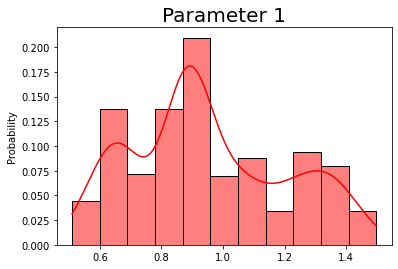

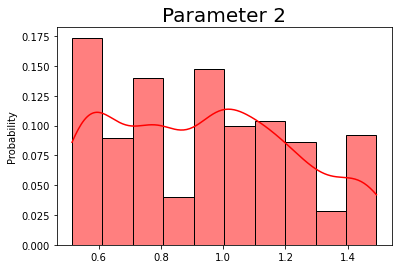

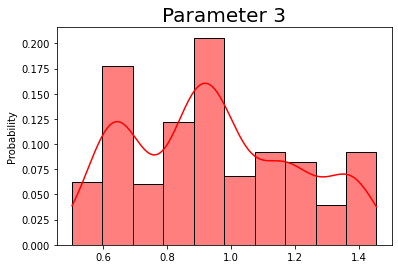

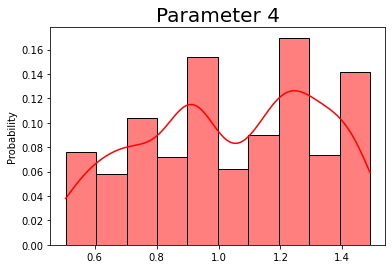

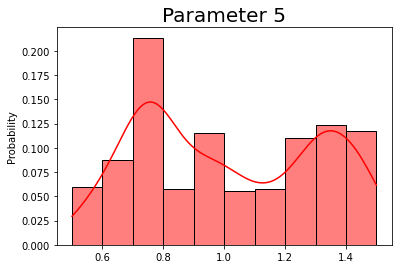

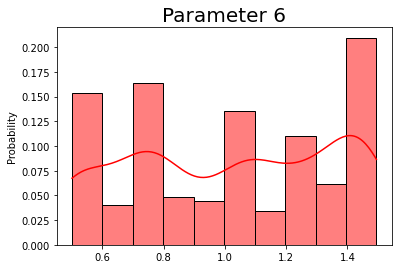

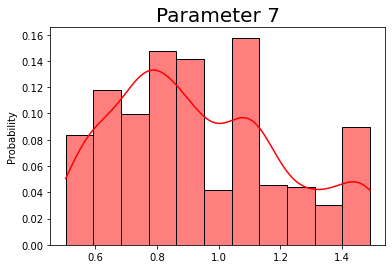

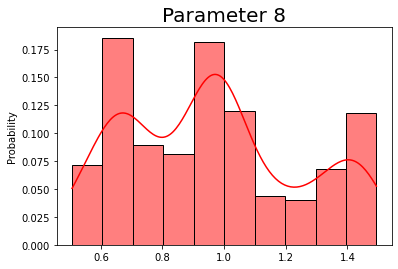

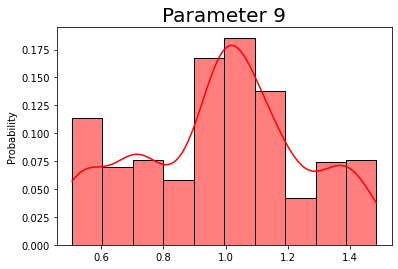

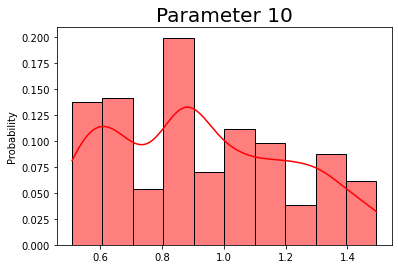

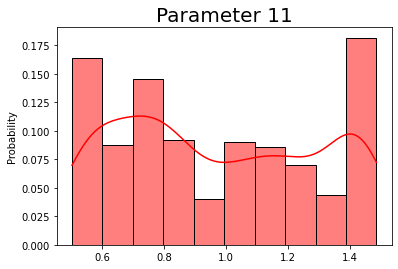

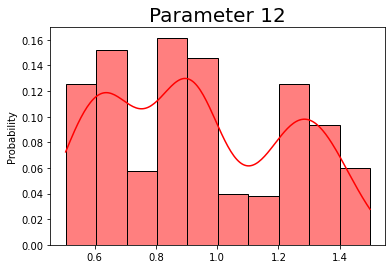

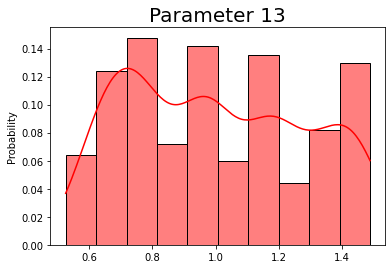

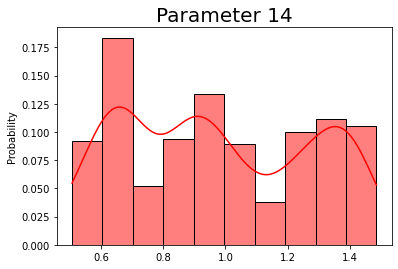

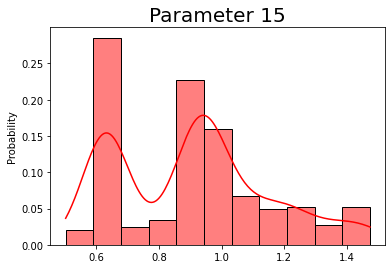

In [ ]:
for i in range(U_HF_test_selection.shape[0]):
    plt.figure()  # Crea una nuova figura per ogni iterazione del ciclo
    rel = sns.histplot(
        data=q[:, i],
        kde=True,
        stat="probability",
        color="r",
        label="probabilities",
    )
    plt.title(f"Parameter {i+1}", fontsize=20)
    plt.show()

In [ ]:
print(np.mean(exp_q,axis=0))
print(reaction_HF_test[permutation][0:n_HF].reshape(n_HF))
print(np.abs(reaction_HF_test[permutation][0:n_HF].reshape(n_HF)-np.mean(exp_q,axis=0)))

[0.9245653  0.99121495 0.91724571 1.0000204  1.00895473 1.01032582
 0.9891536  0.97359924 0.99745004 0.95818387 1.00441223 0.95880259
 0.99849326 0.98502346 0.92657489]
[1.03061224 0.56122449 1.23469388 1.09183673 1.13265306 0.90816327
 0.94897959 1.45918367 0.74489796 0.84693878 0.8877551  0.76530612
 0.92857143 0.86734694 1.25510204]
[0.10604695 0.42999046 0.31744816 0.09181633 0.12369834 0.10216256
 0.040174   0.48558444 0.25255208 0.11124509 0.11665713 0.19349646
 0.06992183 0.11767652 0.32852715]


In [ ]:
# OBS: anche cosi viene ancora tutto simile a 1

\sigma =0.5 

[0.9245653  0.99121495 0.91724571 1.0000204  1.00895473 1.01032582
 0.9891536  0.97359924 0.99745004 0.95818387 1.00441223 0.95880259
 0.99849326 0.98502346 0.92657489]
[1.03061224 0.56122449 1.23469388 1.09183673 1.13265306 0.90816327
 0.94897959 1.45918367 0.74489796 0.84693878 0.8877551  0.76530612
 0.92857143 0.86734694 1.25510204]
[0.10604695 0.42999046 0.31744816 0.09181633 0.12369834 0.10216256
 0.040174   0.48558444 0.25255208 0.11124509 0.11665713 0.19349646
 0.06992183 0.11767652 0.32852715]